In [150]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler, PowerTransformer
from sklearn.linear_model import LinearRegression
import plotly.express as px

In [151]:
db = pd.read_csv("data/train.csv")
db.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [152]:
db["SalePrice"].max()

np.int64(755000)

In [153]:
info = db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Creating Functions for managing various custom operations in this notebook

## Creating a function for identifying numerical and categorical columns to better manage features

In [154]:
def automate_colms(cols):
    cata_cols = []
    num_cols = []
    for i in cols:
        if db[i].dtype == "object" or db[i].dtype == "category":
            cata_cols.append(i)
        elif db[i].dtype in ["int64", "float64", "int32", "float32"]:
             if i not in ['Id', 'SalePrice']:
                num_cols.append(i)
        else:
            cata_cols.append(i)
    return cata_cols, num_cols

# Handling Null Values

## Identifying null columns

In [155]:
def print_null(db):
    drop_cols = []
    null_cols = []
    for i in db.columns:
        if db[i].isna().sum() > 0:
            percentage = round((db[i].isna().sum()/db[i].count())* 100, 2)
            if percentage >= 10:
                drop_cols.append(i)
                print(f"{i}: {percentage}")
            else:
                null_cols.append(i)
                print(f"{i}: {percentage}")
    return drop_cols, null_cols

drop_cols, null_cols = print_null(db)

LotFrontage: 21.57
Alley: 1504.4
MasVnrType: 148.3
MasVnrArea: 0.55
BsmtQual: 2.6
BsmtCond: 2.6
BsmtExposure: 2.67
BsmtFinType1: 2.6
BsmtFinType2: 2.67
Electrical: 0.07
FireplaceQu: 89.61
GarageType: 5.87
GarageYrBlt: 5.87
GarageFinish: 5.87
GarageQual: 5.87
GarageCond: 5.87
PoolQC: 20757.14
Fence: 419.57
MiscFeature: 2603.7


## Dropping features which have null values more than 10% of total feature values

In [156]:
db = db.drop(columns=drop_cols, axis=1)

## Printing rest columns with null values 

In [157]:
drop_cols, null_cols = print_null(db)

MasVnrArea: 0.55
BsmtQual: 2.6
BsmtCond: 2.6
BsmtExposure: 2.67
BsmtFinType1: 2.6
BsmtFinType2: 2.67
Electrical: 0.07
GarageType: 5.87
GarageYrBlt: 5.87
GarageFinish: 5.87
GarageQual: 5.87
GarageCond: 5.87


## Identifying the type of features with null values ie: numerical or categorical

In [158]:
null_cata, null_num = automate_colms(null_cols)
print(f"Null Catagorical Columns: {null_cata}, Null Numerical Columns: {null_num}")

Null Catagorical Columns: ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'], Null Numerical Columns: ['MasVnrArea', 'GarageYrBlt']


## Imputing the values to handle null values for both categorical and numerical null columns

In [159]:
for i in null_cata:
    db[i].fillna(db[i].mode()[0], inplace = True)

for i in null_num:
    db[i].fillna(db[i].median(), inplace = True)

C:\Users\apoor\AppData\Local\Temp\ipykernel_24276\3223594109.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\apoor\AppData\Local\Temp\ipykernel_24276\3223594109.py:5: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

## Checking the updated columns

In [160]:
db.head()

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


## Basemodel using Linear Regression

In [161]:
numerical_columns = db.select_dtypes(include=[np.number]).columns
numerical_columns = numerical_columns[1:-1]
categorical_columns = db.select_dtypes(include=["object"]).columns

### Encoding categorical features using One Hot Encoding

In [162]:

x = db.iloc[:,1:-1]
y = db.iloc[:,-1]

x = pd.get_dummies(x, columns=categorical_columns, drop_first=True)


In [163]:
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)

lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

score = np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Root Mean Squared Error for basemodel: {round(score,2)}")

Root Mean Squared Error for basemodel: 46685.57


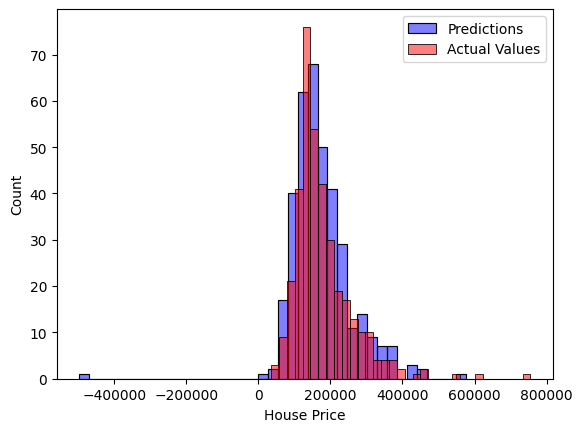

In [164]:
plt.Figure()
sns.histplot(y_pred, color='blue', alpha = 0.5, label = "Predictions")
sns.histplot(y_test, color='red', alpha = 0.5, label = "Actual Values")
plt.xlabel("House Price")
plt.legend()
plt.show()

# Applying various normalization and standardization techniques to identify which technique performs best for Linear Regression

## Identifying numerical and categorical columns

In [165]:
normal_models = {}

x = db.iloc[:, 1:-1]
x = pd.get_dummies(x, columns=categorical_columns, drop_first=True)
x.columns = x.columns.astype(str)
y = db.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)

In [183]:
cols = x.columns
cols

Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=228)

In [167]:
def predict_and_find_error(xtrain, ytrain,xtest,ytest, name):
    lr = LinearRegression()
    lr.fit(xtrain,ytrain)
    
    ypred = lr.predict(xtest)
    score = round(np.sqrt(mean_squared_error(ytest,ypred)),2)
    print(f"Root Mean Squared Error for {name}: {score}")

In [168]:
standard = StandardScaler()
minMax = MinMaxScaler()
robust = RobustScaler()
maxabs = MaxAbsScaler()
power = PowerTransformer()

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
x_train = standard.fit_transform(x_train)
x_test = standard.transform(x_test)
predict_and_find_error(x_train,y_train,x_test,y_test, "StandardSclaer")

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
x_train = minMax.fit_transform(x_train)
x_test = minMax.transform(x_test)
predict_and_find_error(x_train,y_train,x_test,y_test, "MinMaxScaler")

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
x_train = robust.fit_transform(x_train)
x_test = robust.transform(x_test)
predict_and_find_error(x_train,y_train,x_test,y_test, "RobustScaler")

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
x_train = maxabs.fit_transform(x_train)
x_test = maxabs.transform(x_test)
predict_and_find_error(x_train,y_train,x_test,y_test, "MaxAbsScaler")


x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
x_train = power.fit_transform(x_train)
x_test = power.transform(x_test)
predict_and_find_error(x_train,y_train,x_test,y_test, "PowerTransformer")

Root Mean Squared Error for StandardSclaer: 46685.57
Root Mean Squared Error for MinMaxScaler: 46685.57
Root Mean Squared Error for RobustScaler: 46685.57
Root Mean Squared Error for MaxAbsScaler: 46685.57
Root Mean Squared Error for PowerTransformer: 127730.46


## Observation: Standard Scaler when paired along with power transformer gives the best results with Linear Regression

# Final Model

In [169]:
x = db.iloc[:, 1:-1]
x = pd.get_dummies(x, columns=categorical_columns, drop_first=True)
x.columns = x.columns.astype(str)
y = db.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)
x_train = standard.fit_transform(x_train)
x_test = standard.transform(x_test)

x_train = power.fit_transform(x_train)
x_test = power.transform(x_test)

lr = LinearRegression()

lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)

score = round(np.sqrt(mean_squared_error(y_test,y_pred)),2)

print(f"RMSE after one hot encoding and normalization: {score}")

RMSE after one hot encoding and normalization: 39946.53


## Residue Analysis

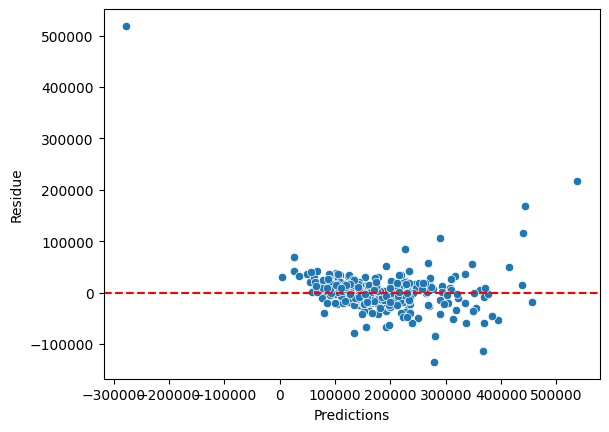

In [170]:
residue = y_test-y_pred
 

plt.figure()
sns.scatterplot(x=y_pred,y=residue)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predictions")
plt.ylabel("Residue")
plt.show()

## Coefficients of Linear Regression

In [187]:
coefficients = pd.DataFrame(lr.coef_, index=cols)
coefficients = round(coefficients,2)
coefficients = coefficients.abs().sort_values(by=0,ascending=False)
print(coefficients)

                         0
RoofMatl_CompShg  64648.89
RoofMatl_Tar&Grv  44643.19
GarageQual_TA     34538.44
RoofMatl_WdShngl  31457.74
GarageCond_TA     31164.99
...                    ...
MiscVal               8.97
Condition2_PosA       0.00
Condition2_RRNn       0.00
RoofMatl_Membran      0.00
Electrical_Mix        0.00

[228 rows x 1 columns]


## Observations: 
1. Outliers
2. Unbalanced Y Axis
3. Heteroskedasticity

Solution: Transforming the features